# High Value Habits: category breadth and future engagement

**Question:** Among already-engaged retail households, is shopping across a wider range of product categories associated with stronger future engagement?

**Design**
- **Observation window:** weeks 1–52
- **Outcome window:** weeks 53–102
- **Primary outcome:** future shopping trips
- **Operational "high value" definition:** top quartile of future trip frequency

This is an **association study**, not a causal estimate. The dataset contains frequent shoppers, so conclusions apply to deepening engagement among an already-engaged population—not to acquiring or retaining the average retail customer.

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import kagglehub

# Download the Complete Journey data.
path = kagglehub.dataset_download("frtgnn/dunnhumby-the-complete-journey")

transactions = pd.read_csv(os.path.join(path, "transaction_data.csv"))
products = pd.read_csv(os.path.join(path, "product.csv"))
demographics = pd.read_csv(os.path.join(path, "hh_demographic.csv"))

print("Transactions:", transactions.shape)
print("Products:", products.shape)
print("Demographics:", demographics.shape)

/Users/santiagonovoa/walmart/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Transactions: (2595732, 12)
Products: (92353, 7)
Demographics: (801, 8)


## 1. Sanity-check the data

`transaction_data.csv` is at the product-line level, so `BASKET_ID`—not row count—is used to measure shopping trips.

Demographics are available for only a subset of households. They are loaded for possible follow-up analysis, but are **not merged into the core transaction table** because the main question can be answered from transaction behavior alone.

In [3]:
assert products["PRODUCT_ID"].is_unique
assert demographics["household_key"].is_unique

print("Households:", transactions["household_key"].nunique())
print("Baskets:", transactions["BASKET_ID"].nunique())
print("Products purchased:", transactions["PRODUCT_ID"].nunique())
print("Weeks:", transactions["WEEK_NO"].min(), "to", transactions["WEEK_NO"].max())
print("Households with demographics:", demographics["household_key"].nunique())

# Product metadata is needed to measure category breadth.
df = transactions.merge(
    products,
    on="PRODUCT_ID",
    how="left",
    validate="m:1"
)

print("Missing COMMODITY_DESC:", f'{df["COMMODITY_DESC"].isna().mean():.2%}')

Households: 2500
Baskets: 276484
Products purchased: 92339
Weeks: 1 to 102
Households with demographics: 801
Missing COMMODITY_DESC: 0.00%


## 2. Build a household-level analysis table

The first 52 weeks describe existing behavior. The following 50 weeks measure future engagement.

The main candidate habit is **category breadth**: the number of distinct `COMMODITY_DESC` categories a household bought from during weeks 1–52.

In [4]:
past = df[df["WEEK_NO"] <= 52].copy()
future = df[df["WEEK_NO"] > 52].copy()

past_behavior = (
    past.groupby("household_key")
    .agg(
        trips=("BASKET_ID", "nunique"),
        spend=("SALES_VALUE", "sum"),
        active_weeks=("WEEK_NO", "nunique"),
        commodity_breadth=("COMMODITY_DESC", "nunique")
    )
    .reset_index()
)

future_value = (
    future.groupby("household_key")
    .agg(
        future_trips=("BASKET_ID", "nunique"),
        future_spend=("SALES_VALUE", "sum"),
        future_active_weeks=("WEEK_NO", "nunique")
    )
    .reset_index()
)

analysis = past_behavior.merge(
    future_value,
    on="household_key",
    how="left",
    validate="1:1"
)

analysis[["future_trips", "future_spend", "future_active_weeks"]] = (
    analysis[["future_trips", "future_spend", "future_active_weeks"]]
    .fillna(0)
)

# "High value" is operationalized as the top quartile of future trip frequency.
high_value_threshold = analysis["future_trips"].quantile(0.75)
analysis["high_value"] = (
    analysis["future_trips"] >= high_value_threshold
).astype(int)

print("Households in analysis:", len(analysis))
print("High-value threshold:", high_value_threshold, "future trips")
print("High-value share:", f'{analysis["high_value"].mean():.1%}')

Households in analysis: 2497
High-value threshold: 78.0 future trips
High-value share: 25.6%


In [5]:
analysis

,household_key,trips,spend,active_weeks,commodity_breadth,future_trips,future_spend,future_active_weeks,high_value
0,1,35,2011.66,32,110,51.0,2318.50,36.0,0
1,2,28,990.19,20,108,17.0,964.15,15.0,0
2,3,29,2014.03,20,98,18.0,639.18,17.0,0
3,4,22,980.21,18,57,8.0,219.90,8.0,0
4,5,22,505.59,14,64,18.0,273.47,13.0,0
...,...,...,...,...,...,...,...,...,...
2492,2496,24,1743.10,19,103,39.0,2596.56,29.0,0
2493,2497,107,3159.82,40,142,114.0,3952.16,46.0,1
2494,2498,65,893.60,22,93,107.0,1708.00,45.0,1
2495,2499,45,1050.47,26,102,45.0,2343.60,28.0,0


## 3. Start with the raw relationship

First ask the simple question: do households with broader category adoption in weeks 1–52 look more engaged later?

This is deliberately **unadjusted**. The point is to see the pattern first, then challenge it.

In [4]:
analysis["breadth_quartile"] = pd.qcut(
    analysis["commodity_breadth"],
    4,
    labels=["Q1", "Q2", "Q3", "Q4"]
)

breadth_summary = (
    analysis.groupby("breadth_quartile", observed=True)
    .agg(
        households=("household_key", "count"),
        avg_past_trips=("trips", "mean"),
        avg_future_trips=("future_trips", "mean"),
        avg_future_spend=("future_spend", "mean"),
        high_value_rate=("high_value", "mean")
    )
)

breadth_summary

,households,avg_past_trips,avg_future_trips,avg_future_spend,high_value_rate
breadth_quartile,,,,,
Q1,625,14.539200,24.116800,500.433024,0.035200
Q2,627,32.639553,42.031898,1048.120797,0.141946
Q3,635,53.664567,61.683465,1751.519496,0.261417
Q4,610,105.454098,111.308197,3870.031328,0.591803


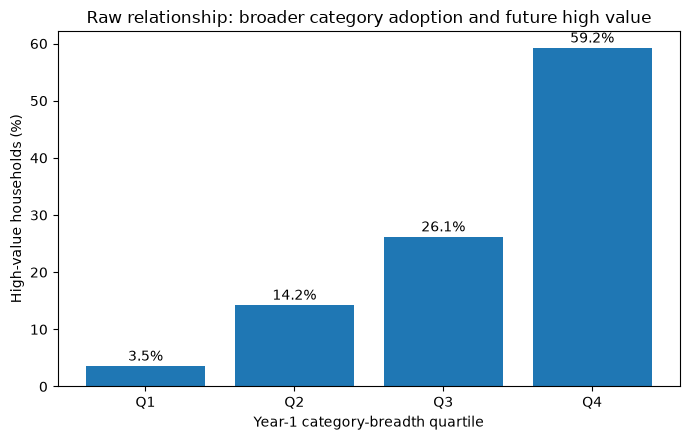

In [5]:
# Raw visual: high-value rate rises sharply with category breadth.
plot_data = breadth_summary.reset_index()

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(
    plot_data["breadth_quartile"].astype(str),
    plot_data["high_value_rate"] * 100
)

ax.set_title("Raw relationship: broader category adoption and future high value")
ax.set_xlabel("Year-1 category-breadth quartile")
ax.set_ylabel("High-value households (%)")

for bar, value in zip(bars, plot_data["high_value_rate"] * 100):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{value:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

### The obvious problem: existing engagement is a confounder

The raw relationship is striking, but high-breadth households also shop much more often already. A household with more trips has more opportunities to buy from more categories—and prior trip frequency is itself strongly related to future trip frequency.

So the relevant question becomes:

> **Does category breadth contain information about future engagement beyond how frequently and how much the household already shopped?**

In [6]:
# Keep the confounding check focused on the variables that matter to the story.
analysis[
    ["trips", "spend", "commodity_breadth", "future_trips"]
].corr().round(2)

,trips,spend,commodity_breadth,future_trips
trips,1.00,0.70,0.64,0.78
spend,0.70,1.00,0.82,0.58
commodity_breadth,0.64,0.82,1.00,0.53
future_trips,0.78,0.58,0.53,1.00


## 4. Adjust for baseline engagement

Trip counts and spend are highly skewed, so use `log1p` transforms. The model predicts future trip frequency while controlling for:
- prior trip frequency
- prior spend
- category breadth

HC3 robust standard errors make inference less sensitive to heteroskedasticity.

In [7]:
analysis["log_trips"] = np.log1p(analysis["trips"])
analysis["log_spend"] = np.log1p(analysis["spend"])
analysis["log_future_trips"] = np.log1p(analysis["future_trips"])
analysis["commodity_breadth_10"] = analysis["commodity_breadth"] / 10

model = smf.ols(
    "log_future_trips ~ log_trips + log_spend + commodity_breadth_10",
    data=analysis
).fit(cov_type="HC3")

coef = model.params["commodity_breadth_10"]
effect_pct = (np.exp(coef) - 1) * 100
p_value = model.pvalues["commodity_breadth_10"]

print(f"R-squared: {model.rsquared:.3f}")
print(f"Category-breadth coefficient (per 10 categories): {coef:.4f}")
print(f"Approx. association with future trips: {effect_pct:.1f}%")
print(f"p-value: {p_value:.4g}")
print()
print(
    "Interpretation: holding prior trip frequency and prior spend constant, "
    f"10 additional Year-1 categories are associated with about {effect_pct:.1f}% "
    "more trips in the future period."
)

R-squared: 0.550
Category-breadth coefficient (per 10 categories): 0.0359
Approx. association with future trips: 3.7%
p-value: 9.043e-05

Interpretation: holding prior trip frequency and prior spend constant, 10 additional Year-1 categories are associated with about 3.7% more trips in the future period.


## 5. Make the adjusted result intuitive

The figure below varies Year-1 category breadth while holding prior trip frequency and prior spend at their sample medians.

It is a visualization of the **adjusted association**, not a causal effect.

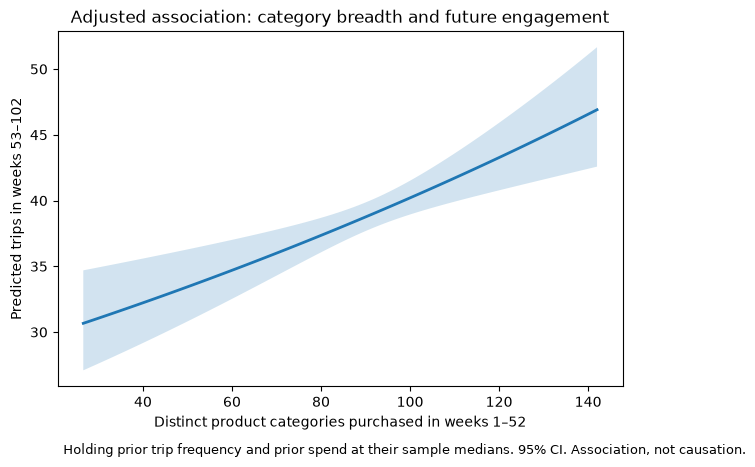

In [8]:
# Show the model-adjusted relationship over the central 80% of observed breadth.
breadth_grid = np.linspace(
    analysis["commodity_breadth"].quantile(0.10),
    analysis["commodity_breadth"].quantile(0.90),
    100
)

prediction_data = pd.DataFrame({
    "log_trips": np.log1p(analysis["trips"].median()),
    "log_spend": np.log1p(analysis["spend"].median()),
    "commodity_breadth_10": breadth_grid / 10
})

pred = model.get_prediction(prediction_data).summary_frame(alpha=0.05)

prediction_data["pred_future_trips"] = np.expm1(pred["mean"])
prediction_data["lower"] = np.expm1(pred["mean_ci_lower"])
prediction_data["upper"] = np.expm1(pred["mean_ci_upper"])

fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.plot(
    breadth_grid,
    prediction_data["pred_future_trips"],
    linewidth=2
)
ax.fill_between(
    breadth_grid,
    prediction_data["lower"],
    prediction_data["upper"],
    alpha=0.2
)

ax.set_title("Adjusted association: category breadth and future engagement")
ax.set_xlabel("Distinct product categories purchased in weeks 1–52")
ax.set_ylabel("Predicted trips in weeks 53–102")

ax.text(
    0.01, -0.19,
    "Holding prior trip frequency and prior spend at their sample medians. 95% CI. Association, not causation.",
    transform=ax.transAxes,
    fontsize=9
)

plt.tight_layout()
plt.show()

## Observations

 In the current run, the highest category-breadth quartile had a high-value rate of about **59%**, versus about **3.5%** in the lowest quartile. But the highest-breadth households were also much more active to begin with.

 After controlling for prior trip frequency and prior spend, the relationship remained positive. In the current run, **10 additional Year-1 product categories were associated with roughly 3–4% more future trips**.

**Interpretation.** Category breadth is therefore a plausible **candidate High Value Habit**: households whose relationship with the retailer spans more of their shopping needs tend to remain more deeply engaged later, even after accounting for baseline frequency and spend.

**What this does *not* prove.** It does not show that causing a household to enter another category will increase loyalty. The dataset is observational and consists of frequent shoppers, so selection and unobserved differences remain.

**Causal next step.** Test an intervention that encourages relevant cross-category adoption among comparable customers, then measure incremental future engagement versus a control group.



### 30-second interview version

> I used a public longitudinal retail dataset to think through the High Value Habits problem. I looked at whether shopping across a wider range of product categories in the first year was associated with stronger engagement later. The raw relationship was huge, but those households were also already shopping much more frequently, so I did not trust it at face value. After controlling for prior trip frequency and spend, category breadth still had incremental signal: ten additional categories were associated with roughly 3–4% more future trips. I would call that a candidate High Value Habit, not a causal result. The next question would be whether an intervention that encourages relevant cross-category adoption actually creates incremental engagement.